# 03 — Exploratory Data Analysis (EDA)

**Project:** Healthcare Readmission Intelligence  
**Input:** `data/processed/train.csv` (output of `02_data_preprocessing.ipynb`)

## Objective

Understand the processed training dataset, identify patterns, detect issues,
and gain insights that will guide feature engineering and model development.

**Only the training set is used here** to prevent information leakage from the test set.

## Setup

In [51]:
import warnings
import os
import sys
import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

In [52]:
sys.path.append(os.path.abspath('..'))

from configs.features import (
    NUMERICAL_FEATURES,
    CLINICAL_FEATURES,
    MEDICATION_FEATURES,
    DEMOGRAPHIC_FEATURES
)

numerical_cols   = NUMERICAL_FEATURES
categorical_cols = CLINICAL_FEATURES + MEDICATION_FEATURES + DEMOGRAPHIC_FEATURES

print("Numerical Columns")
print("-" * 20)
display(numerical_cols)

print("\n" + "=" * 40)
print("Categorical Columns")
print("-" * 20)
display(categorical_cols)

Numerical Columns
--------------------


['time_in_hospital',
 'num_lab_procedures',
 'num_procedures',
 'num_medications',
 'number_outpatient',
 'number_emergency',
 'number_inpatient',
 'number_diagnoses']


Categorical Columns
--------------------


['medical_specialty_group',
 'diag_1_group',
 'diag_2_group',
 'diag_3_group',
 'max_glu_serum',
 'A1Cresult',
 'change',
 'diabetesMed',
 'metformin',
 'repaglinide',
 'nateglinide',
 'chlorpropamide',
 'glimepiride',
 'acetohexamide',
 'glipizide',
 'glyburide',
 'tolbutamide',
 'pioglitazone',
 'rosiglitazone',
 'acarbose',
 'miglitol',
 'troglitazone',
 'tolazamide',
 'examide',
 'citoglipton',
 'insulin',
 'glyburide-metformin',
 'glipizide-metformin',
 'glimepiride-pioglitazone',
 'metformin-rosiglitazone',
 'metformin-pioglitazone',
 'race',
 'gender',
 'age']

## Load Data

In [53]:
CONFIG_PATH = '../configs/paths.yaml'

with open(CONFIG_PATH,"r") as file:
    path = yaml.safe_load(file)

df = pd.read_csv(path['processed_data']['train_data'])
print(df.shape)
df.head()

(81477, 45)


,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted_binary,diag_1_group,diag_2_group,diag_3_group,medical_specialty_group
0,Caucasian,Female,[0-10),6,25,1,1,NaN,41,0,1,0,0,0,1,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,0,Diabetes,Unknown,Unknown,Pediatrics
1,Caucasian,Female,[10-20),1,1,7,3,NaN,59,0,18,0,0,0,9,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,0,Other,Diabetes,Other,Missing
2,AfricanAmerican,Female,[20-30),1,1,7,2,NaN,11,5,13,2,0,1,6,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,0,Other,Diabetes,Other,Missing
3,Caucasian,Male,[30-40),1,1,7,2,NaN,44,1,16,0,0,0,7,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,0,Other,Diabetes,Circulatory,Missing
4,Caucasian,Male,[50-60),2,1,2,3,NaN,31,6,16,0,0,0,9,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,Yes,0,Circulatory,Circulatory,Diabetes,Missing


In [54]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 81477 entries, 0 to 81476
Data columns (total 45 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   race                      79680 non-null  str  
 1   gender                    81477 non-null  str  
 2   age                       81477 non-null  str  
 3   admission_type_id         81477 non-null  int64
 4   discharge_disposition_id  81477 non-null  int64
 5   admission_source_id       81477 non-null  int64
 6   time_in_hospital          81477 non-null  int64
 7   payer_code                49263 non-null  str  
 8   num_lab_procedures        81477 non-null  int64
 9   num_procedures            81477 non-null  int64
 10  num_medications           81477 non-null  int64
 11  number_outpatient         81477 non-null  int64
 12  number_emergency          81477 non-null  int64
 13  number_inpatient          81477 non-null  int64
 14  number_diagnoses          81477 non-null  int64
 

## Missing Values

In [5]:
missing = df.isnull().mean().mul(100).sort_values(ascending=False)
missing[missing > 0]

payer_code    39.537538
race           2.205530
dtype: float64

#### Observation

- `payer_code` has ~39.5% missing 
- `race` has ~2.2% missing 
- The remaining missing values are intentionally preserved.

- These missing values will be handled later using Scikit-learn preprocessing
pipelines (`SimpleImputer`) during model training.


## Target Distribution

In [21]:
df['readmitted_binary'].value_counts(normalize=True)*100

readmitted_binary
0    88.723198
1    11.276802
Name: proportion, dtype: float64

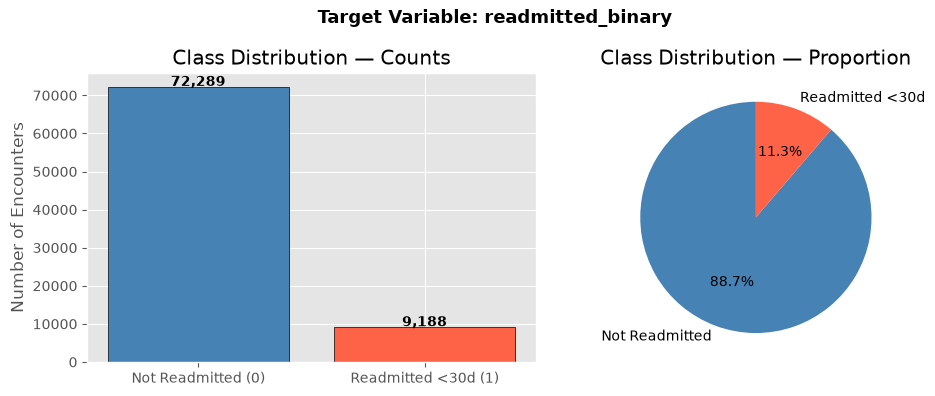

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Count plot
counts = df['readmitted_binary'].value_counts()
axes[0].bar(['Not Readmitted (0)', 'Readmitted <30d (1)'],
            counts.values, color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Class Distribution — Counts')
axes[0].set_ylabel('Number of Encounters')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')

# Percentage pie
axes[1].pie(counts.values, labels=['Not Readmitted', 'Readmitted <30d'],
            colors=['steelblue', 'tomato'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Class Distribution — Proportion')

plt.suptitle('Target Variable: readmitted_binary', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### Observation — Class Imbalance

- **88.7% class 0** (not readmitted within 30 days)
- **11.3% class 1** (readmitted within 30 days)

This is a moderately imbalanced dataset. Using raw accuracy as a metric is misleading —
a model that always predicts 0 gets 88.7% accuracy while being completely useless.

**Strategy:**
- Use `class_weight='balanced'` in all classifiers
- Evaluate with **ROC-AUC, F1 (class 1), and Recall** — not accuracy

## Numerical Features

In [8]:
df[numerical_cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
time_in_hospital,81477.0,4.40,2.99,1.0,2.0,4.0,6.0,14.0
num_lab_procedures,81477.0,43.11,19.65,1.0,31.0,44.0,57.0,132.0
num_procedures,81477.0,1.33,1.70,0.0,0.0,1.0,2.0,6.0
num_medications,81477.0,16.02,8.13,1.0,10.0,15.0,20.0,81.0
number_outpatient,81477.0,0.37,1.25,0.0,0.0,0.0,0.0,42.0
number_emergency,81477.0,0.20,0.96,0.0,0.0,0.0,0.0,76.0
number_inpatient,81477.0,0.64,1.27,0.0,0.0,0.0,1.0,16.0
number_diagnoses,81477.0,7.43,1.93,1.0,6.0,8.0,9.0,16.0


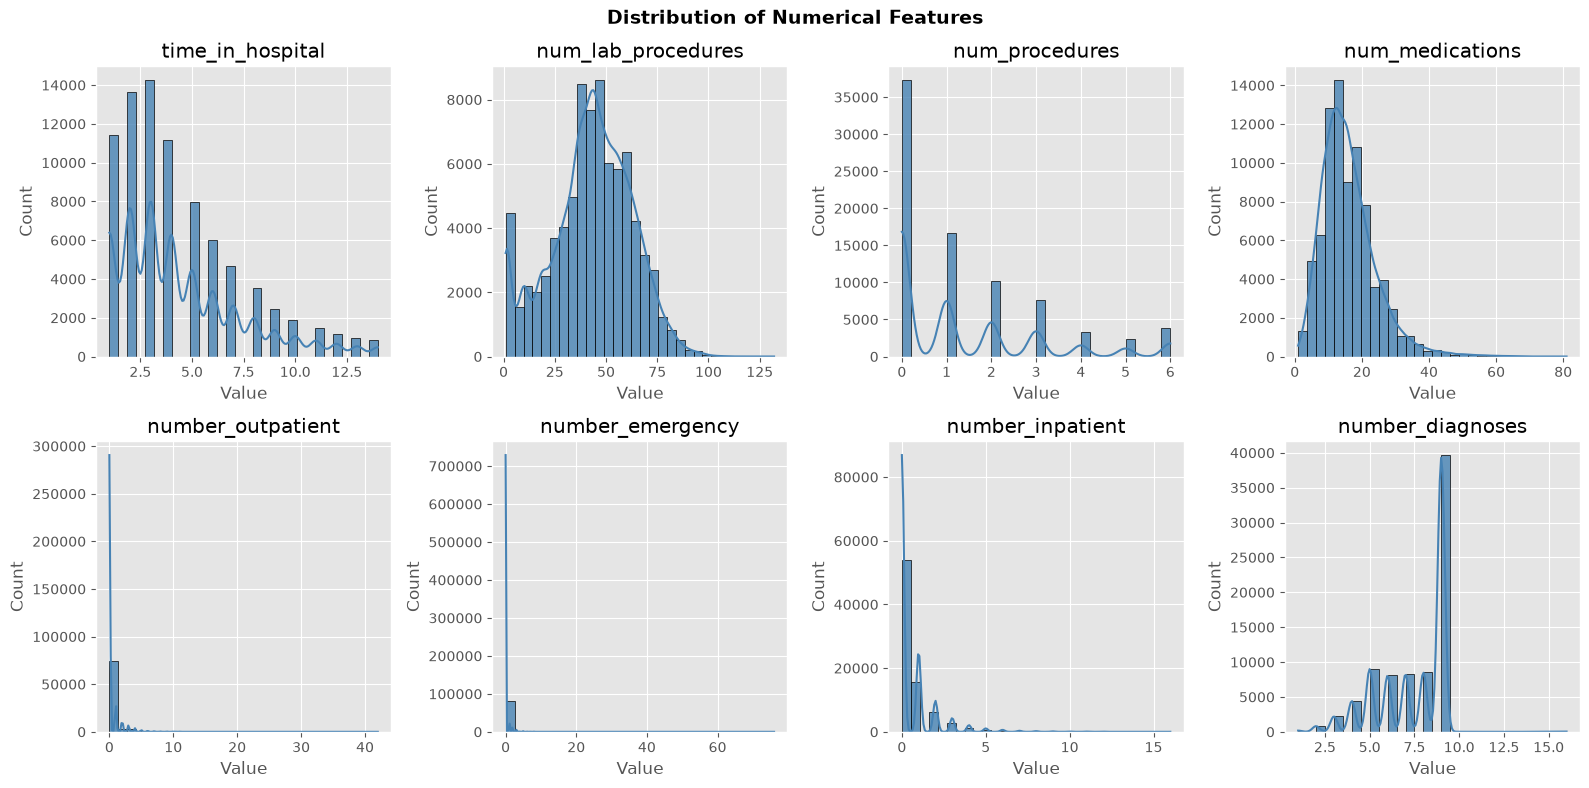

In [35]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], bins=30, color='steelblue', edgecolor='black', alpha=0.8,kde=True,ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

plt.suptitle('Distribution of Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### Observation — Distributions

- `time_in_hospital`: roughly uniform between 1–14 days
- `num_lab_procedures`: right-skewed, most encounters have 30–60 lab tests
- `num_procedures`: most patients have 0–3 procedures
- `num_medications`: roughly normal, centred around 15
- `number_outpatient`, `number_emergency`, `number_inpatient`: heavily right-skewed —
  most patients have 0, but a small number have very high counts (frequent utilizers)
- `number_diagnoses`: concentrated at 9 (the maximum recorded in this dataset)

The outpatient/emergency/inpatient visit counts will likely be strong predictors —
prior hospitalization is a known readmission risk factor.

### Numerical Features vs Target

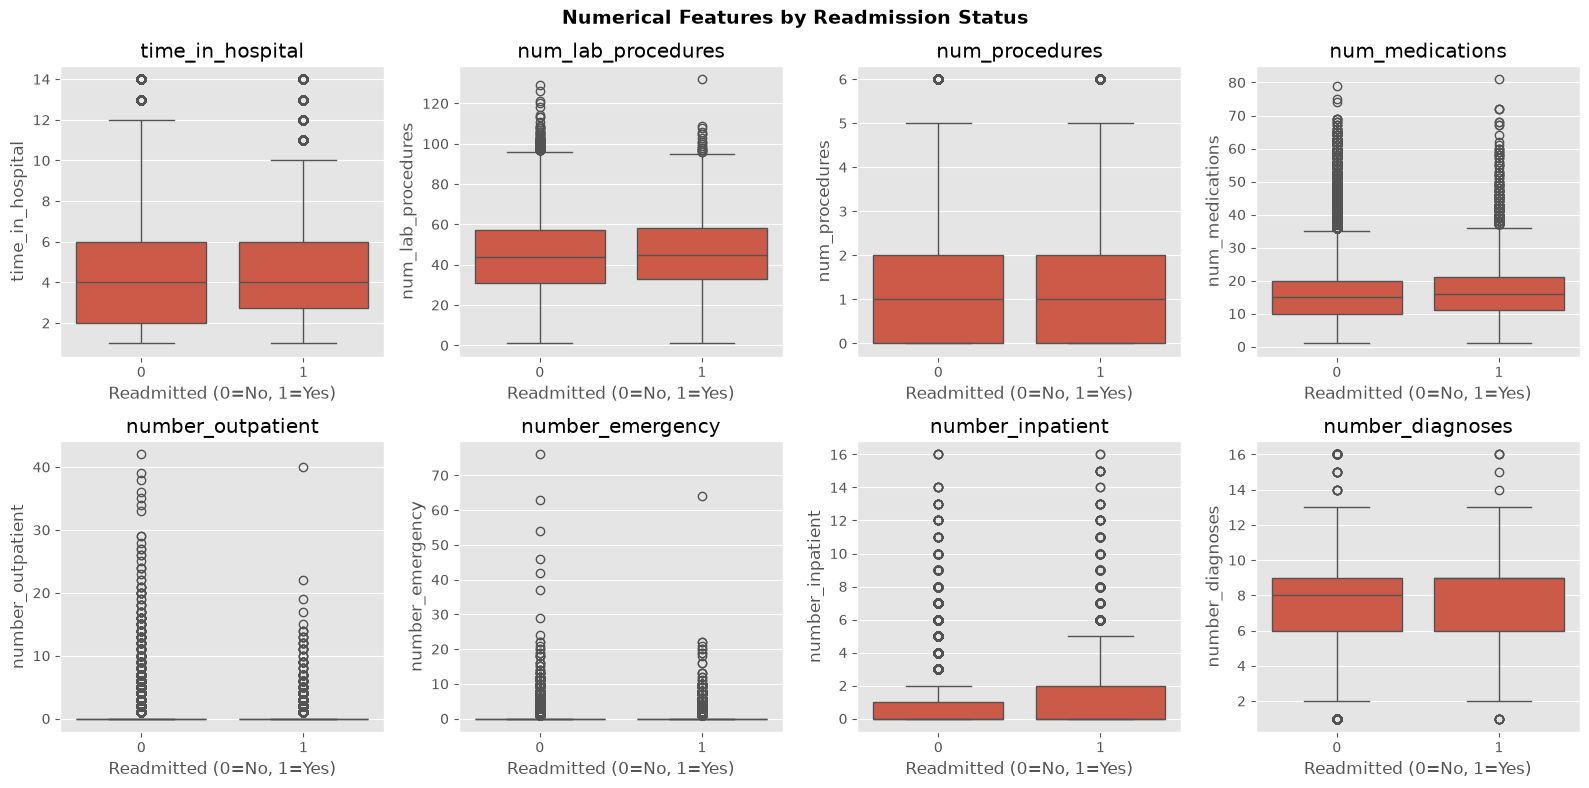

In [39]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(data = df, x='readmitted_binary',y = col, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('Readmitted (0=No, 1=Yes)')

plt.suptitle('Numerical Features by Readmission Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### Observation — Numerical vs Target

- `number_inpatient`: readmitted patients (class 1) have notably higher prior inpatient visits
  — this is likely the strongest single numerical predictor
- `num_medications`: class 1 patients tend to be on more medications (sicker patients)
- `time_in_hospital`: marginal difference; longer stays slightly correlate with readmission
- `num_lab_procedures`: similar distributions across both classes
- `number_outpatient` / `number_emergency`: some signal, but heavily zero-inflated

### Correlation Heatmap — Numerical Features

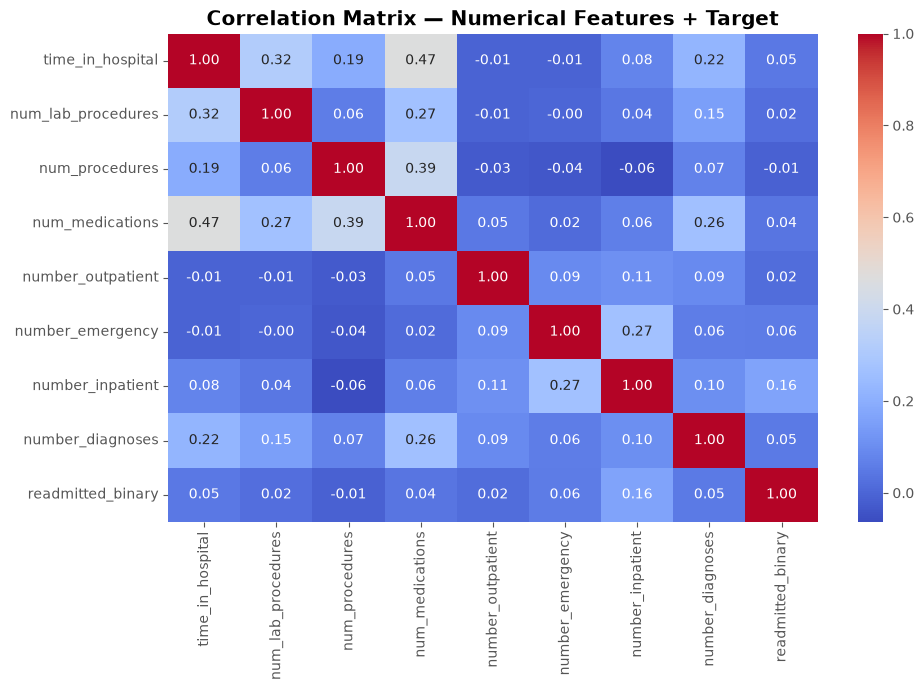

In [24]:
corr = df[numerical_cols + ['readmitted_binary']].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix — Numerical Features + Target', fontweight='bold')
plt.tight_layout()
plt.show()

#### Observation — Correlations

- `number_inpatient` has the highest positive correlation with `readmitted_binary` (~0.16)
- `num_medications` and `number_diagnoses` show weak positive correlation
- Most numerical features are fairly independent of each other (low multicollinearity)
- No pair has correlation > 0.6, so we do not need to drop features for collinearity

## Demographic Features

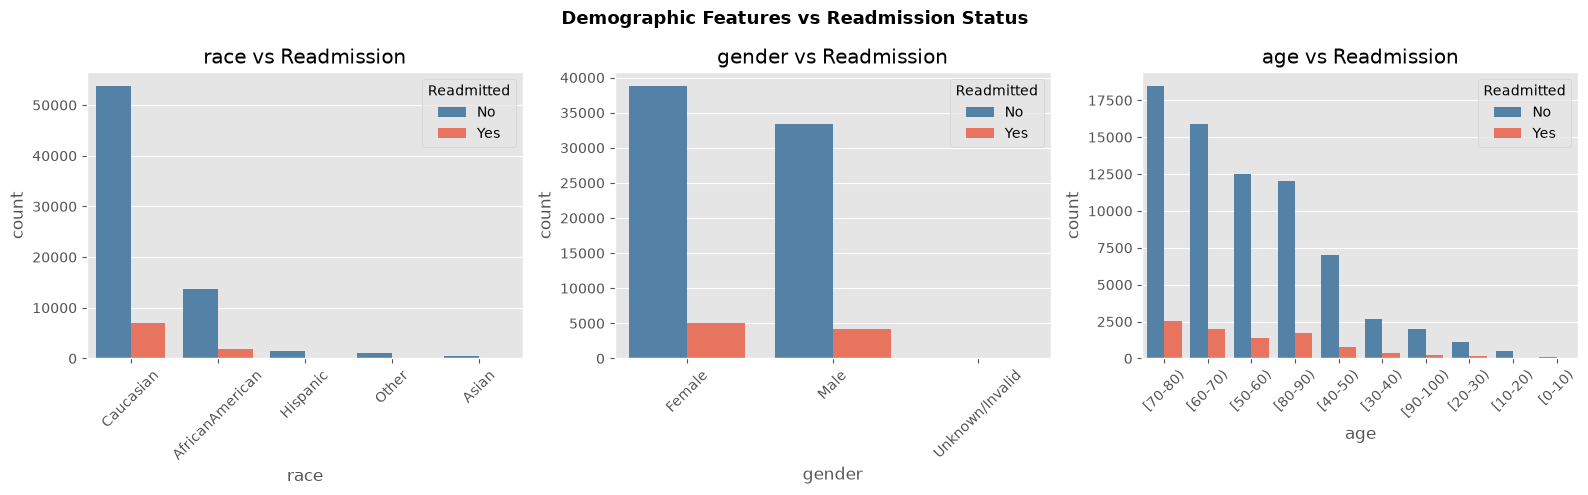

In [12]:
demo_cols = ['race', 'gender', 'age']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(demo_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, ax=axes[i],
                  hue='readmitted_binary', palette={0: 'steelblue', 1: 'tomato'})
    axes[i].set_title(f'{col} vs Readmission')
    axes[i].set_xlabel(col)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(title='Readmitted', labels=['No', 'Yes'])

plt.suptitle('Demographic Features vs Readmission Status', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
for col in demo_cols:
    rate = df.groupby(col)['readmitted_binary'].mean().mul(100).round(2).sort_values(ascending=False)
    print(f"\nReadmission rate by {col}:")
    print(rate.to_string())
    print("-" * 40)


Readmission rate by race:
race
AfricanAmerican    11.51
Caucasian          11.38
Asian              10.65
Hispanic           10.23
Other               9.17
----------------------------------------

Readmission rate by gender:
gender
Female             11.42
Male               11.12
Unknown/Invalid     0.00
----------------------------------------

Readmission rate by age:
age
[20-30)     14.81
[80-90)     12.33
[70-80)     11.93
[30-40)     11.55
[90-100)    11.49
[60-70)     11.09
[40-50)     10.31
[50-60)      9.88
[10-20)      6.67
[0-10)       2.26
----------------------------------------


#### Observation — Demographics

**Race:**
- All racial groups have similar readmission rates (~10–12%)
- `AfricanAmerican` patients have a slightly higher rate — worth noting as a fairness consideration in the final model

**Gender:**
- Male and Female patients have nearly identical readmission rates
- Gender alone is not a strong predictor

**Age:**
- Readmission rate generally increases with age
- Patients aged `[70-80)` and `[80-90)` have the highest rates
- Younger patients `[0-20)` have very low readmission rates
- Age will be an important feature — consider encoding it as an ordinal integer in `04_feature_engineering`

## Clinical Features

In [14]:
clinical_cols = ['admission_type_id', 'discharge_disposition_id',
                 'admission_source_id', 'diag_1_group', 'diag_2_group',
                 'diag_3_group', 'medical_specialty_group']

for col in clinical_cols:
    rate = df.groupby(col)['readmitted_binary'].mean().mul(100).round(2).sort_values(ascending=False)
    print(f"\nReadmission rate by {col}:")
    print(rate.head(8).to_string())
    print("-" * 40)


Readmission rate by admission_type_id:
admission_type_id
4    12.50
1    11.61
6    11.50
2    11.28
5    10.78
3    10.41
8    10.20
7     0.00
----------------------------------------

Readmission rate by discharge_disposition_id:
discharge_disposition_id
12    66.67
15    42.86
28    37.70
9     31.25
22    27.35
5     20.73
2     16.62
8     15.00
----------------------------------------

Readmission rate by admission_source_id:
admission_source_id
22    22.22
3     17.69
20    12.98
5     12.13
9     11.83
7     11.81
2     10.82
1     10.64
----------------------------------------

Readmission rate by diag_1_group:
diag_1_group
Unknown          20.00
Diabetes         13.34
Injury           12.41
Circulatory      11.58
Other            11.52
Genitourinary    11.04
Digestive        10.99
Respiratory       9.81
----------------------------------------

Readmission rate by diag_2_group:
diag_2_group
Neoplasms        14.46
Genitourinary    11.88
Other            11.51
Digestive      

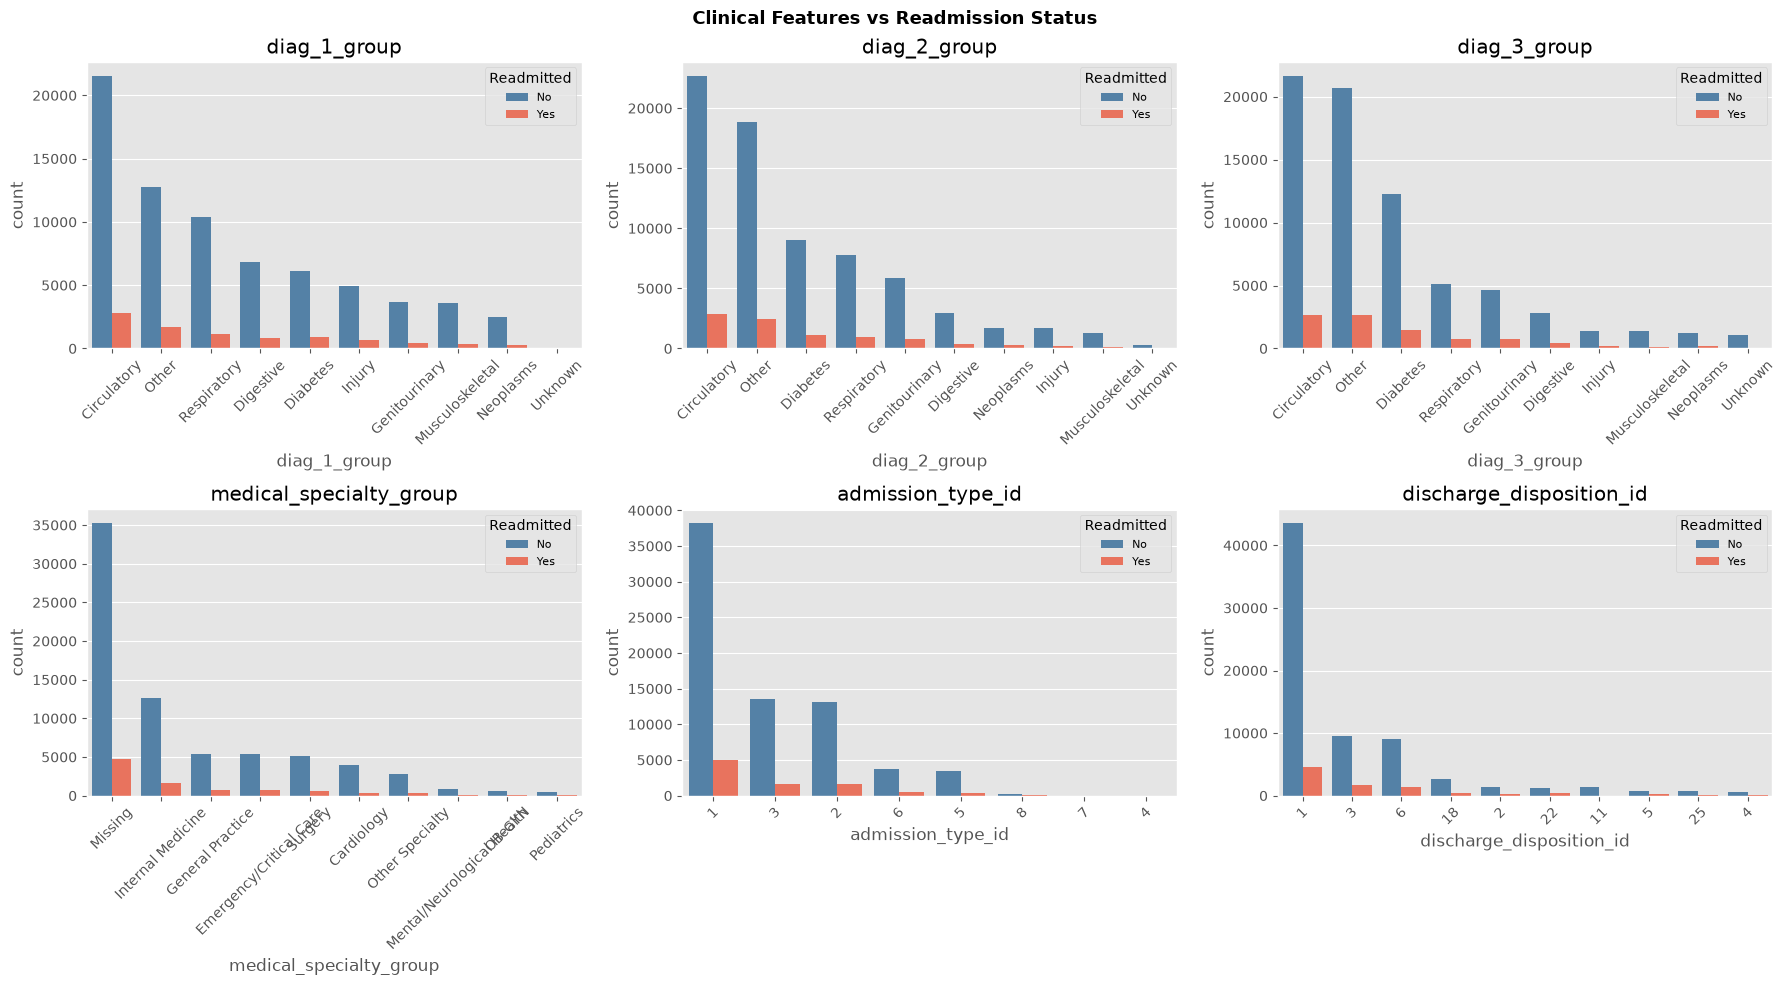

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

plot_cols = ['diag_1_group', 'diag_2_group', 'diag_3_group',
             'medical_specialty_group', 'admission_type_id', 'discharge_disposition_id']

for i, col in enumerate(plot_cols):
    order = df[col].value_counts().index[:10]
    sns.countplot(data=df, x=col, order=order, ax=axes[i],
                  hue='readmitted_binary', palette={0: 'steelblue', 1: 'tomato'})
    axes[i].set_title(f'{col}')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(title='Readmitted', labels=['No', 'Yes'], fontsize=8)

plt.suptitle('Clinical Features vs Readmission Status', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### Observation — Clinical Features

**Diagnosis groups (`diag_1/2/3_group`):**
- `Circulatory` and `Diabetes` are the most common primary diagnoses
- Patients with `Circulatory` as the primary diagnosis have a higher readmission rate
- Diagnosis group will be a useful categorical feature

**Medical specialty:**
- `InternalMedicine` and `Emergency/Trauma` are the most frequent
- `Cardiology` patients have an above-average readmission rate — consistent with circulatory diagnoses

**Admission type:**
- Emergency admissions dominate the dataset
- Elective admissions have lower readmission rates (patients in better baseline health)

**Discharge disposition:**
- Most patients are discharged to home (code 1)
- Patients discharged to skilled nursing facilities have higher readmission rates

## Medication Features

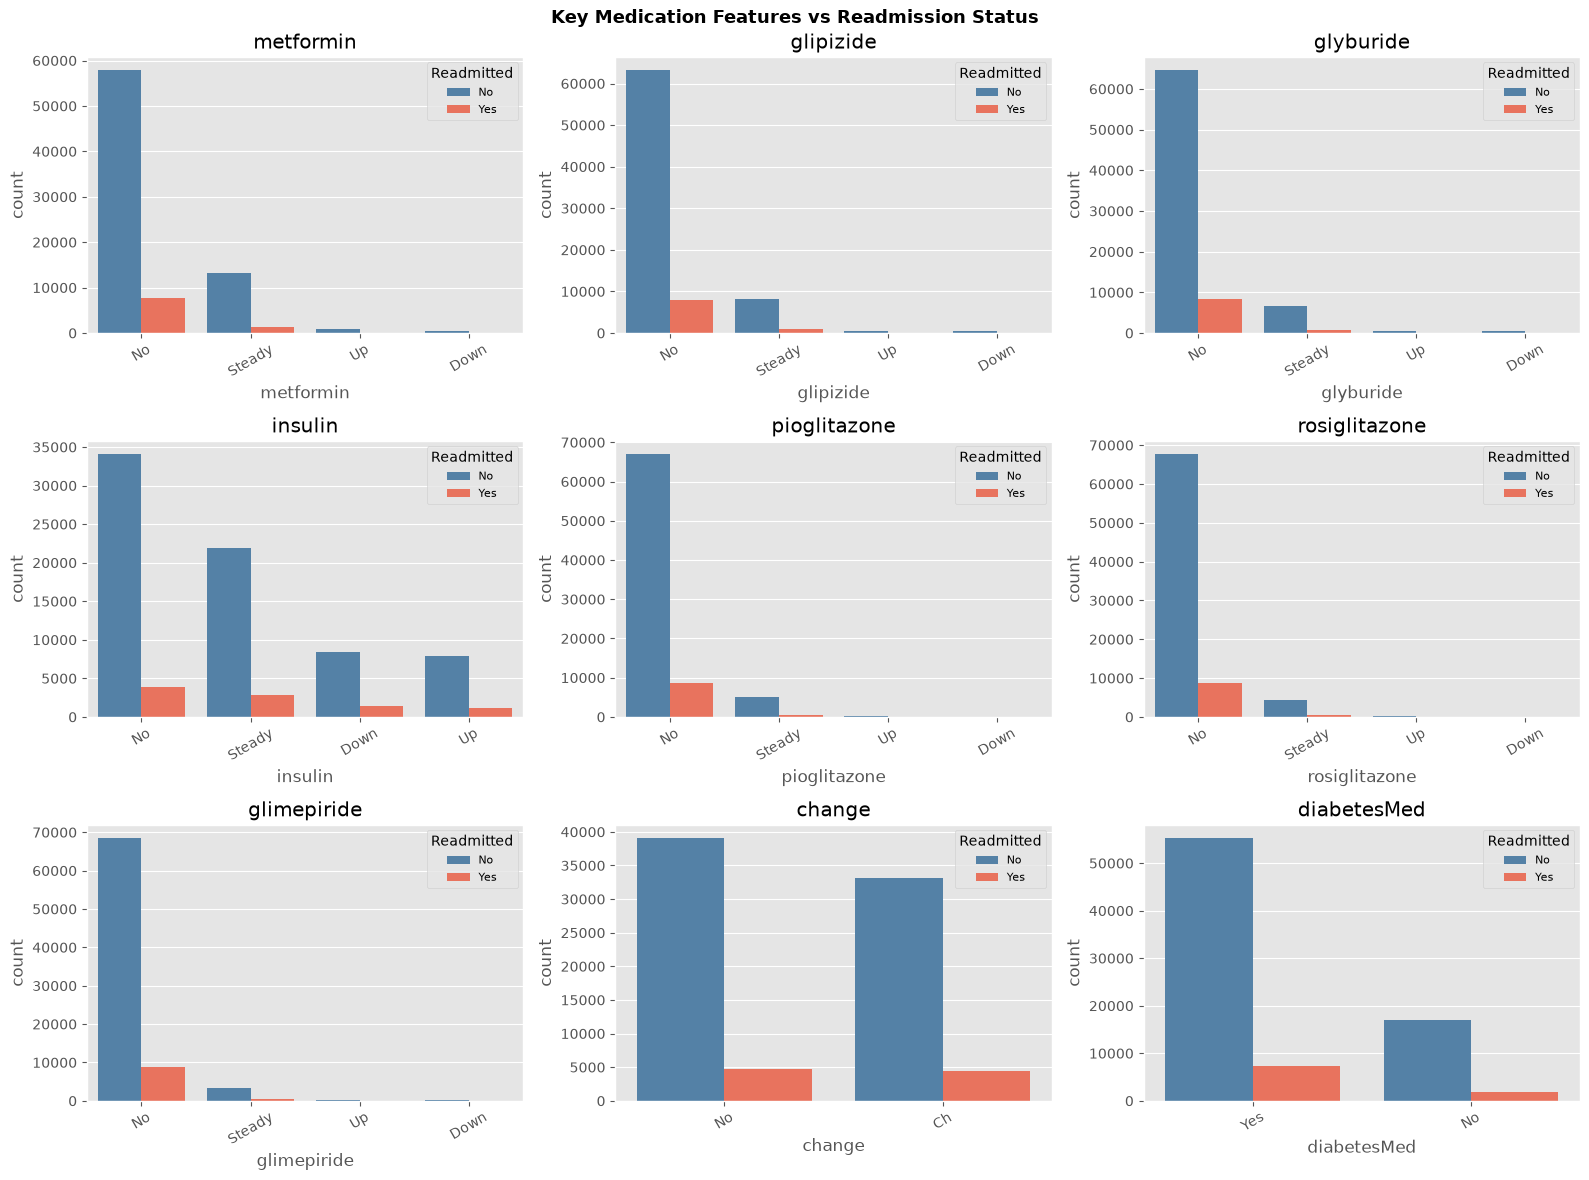

In [46]:
key_meds = ['metformin', 'glipizide', 'glyburide', 'insulin',
            'pioglitazone', 'rosiglitazone', 'glimepiride', 'change', 'diabetesMed']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(key_meds):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, ax=axes[i],
                  hue='readmitted_binary', palette={0: 'steelblue', 1: 'tomato'})
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(title='Readmitted', labels=['No', 'Yes'], fontsize=8)

plt.suptitle('Key Medication Features vs Readmission Status', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [17]:
med_cols = MEDICATION_FEATURES
nzv = {}
for col in med_cols:
    pct_no = (df[col] == 'No').mean()
    nzv[col] = round(pct_no * 100, 1)

nzv_series = pd.Series(nzv).sort_values(ascending=False)
print("% of 'No' (not prescribed) per medication:")
print(nzv_series.to_string())

% of 'No' (not prescribed) per medication:
acetohexamide               100.0
glimepiride-pioglitazone    100.0
glipizide-metformin         100.0
miglitol                    100.0
troglitazone                100.0
tolazamide                  100.0
tolbutamide                 100.0
metformin-rosiglitazone     100.0
metformin-pioglitazone      100.0
citoglipton                 100.0
examide                     100.0
chlorpropamide               99.9
acarbose                     99.7
nateglinide                  99.3
glyburide-metformin          99.3
repaglinide                  98.5
glimepiride                  94.9
rosiglitazone                93.8
pioglitazone                 92.8
glyburide                    89.5
glipizide                    87.4
metformin                    80.5
insulin                      46.6


#### Observation — Medication Features

- `insulin` is the most commonly prescribed medication in this dataset (~53% prescribed)
- Most other medications are prescribed in fewer than 20% of encounters
- **Near-zero-variance medications** (>99% "No"): `acetohexamide`, `tolbutamide`, `troglitazone`,
  `examide`, `citoglipton`, `miglitol`, `tolazamide`, `glimepiride-pioglitazone`,
  `metformin-rosiglitazone`, `metformin-pioglitazone`

  → These should be **dropped in `04_feature_engineering`** — they add noise without signal

- `diabetesMed = 'Yes'` correlates with slightly higher readmission — being on diabetes medication
  indicates the condition is active and being managed, i.e. a sicker patient
- `change = 'Ch'` (medication change during admission) also shows marginal signal

### Insulin — Deeper Look

Readmission rate by insulin status:
insulin
Down      14.11
No        10.19
Steady    11.25
Up        12.84


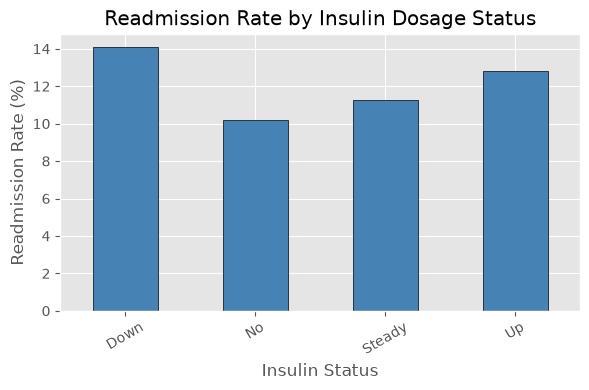

In [49]:
insulin_rate = df.groupby('insulin')['readmitted_binary'].mean().mul(100).round(2)
print("Readmission rate by insulin status:")
print(insulin_rate.to_string())

plt.figure(figsize=(6, 4))
insulin_rate.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Readmission Rate by Insulin Dosage Status')
plt.ylabel('Readmission Rate (%)')
plt.xlabel('Insulin Status')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

#### Observation — Insulin

- Patients with insulin `Up` or `Down` (dose changed during admission) have slightly higher
  readmission rates than those on `Steady` or `No` insulin
- This suggests that **insulin adjustment** is a signal of metabolic instability —
  such patients may be less stable at discharge

This is a good feature to keep as-is (4-category ordinal encoding in `04_feature_engineering`).

## Prior Healthcare Utilization

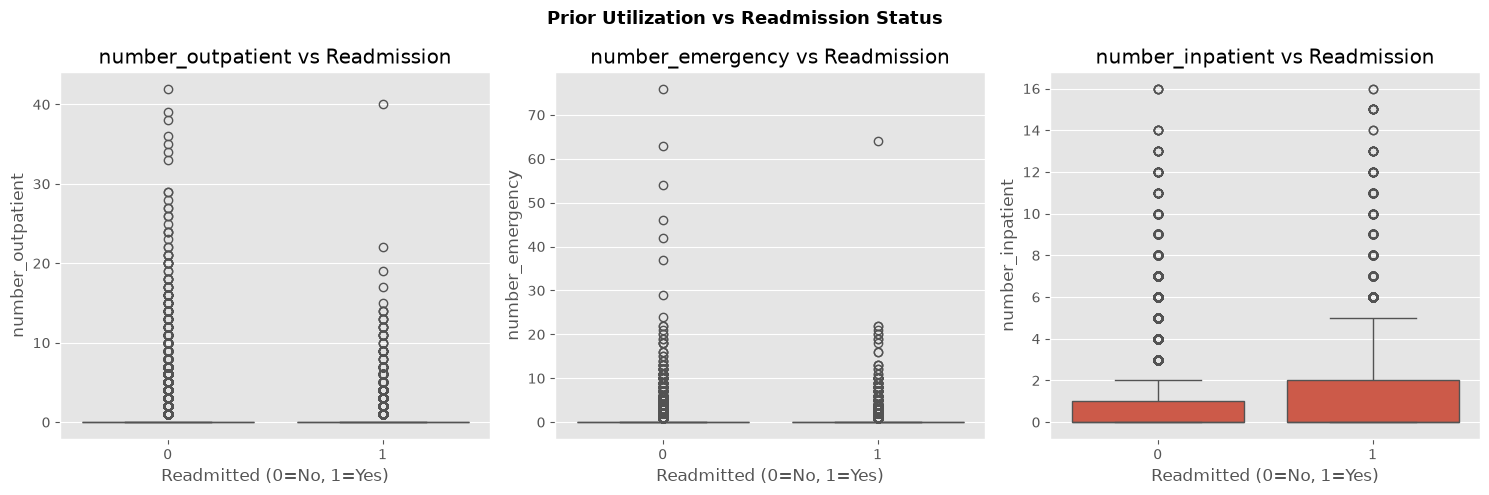

In [27]:
util_cols = ['number_outpatient', 'number_emergency', 'number_inpatient']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(util_cols):
    sns.boxplot(data=df, x='readmitted_binary', y=col, ax=axes[i])
    axes[i].set_title(f'{col} vs Readmission')
    axes[i].set_xlabel('Readmitted (0=No, 1=Yes)')

plt.suptitle('Prior Utilization vs Readmission Status', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [29]:
print("Mean prior utilization by readmission class:")
print(df.groupby('readmitted_binary')[util_cols].mean().round(3))

Mean prior utilization by readmission class:
                   number_outpatient  number_emergency  number_inpatient
readmitted_binary                                                       
0                              0.362             0.183             0.565
1                              0.433             0.353             1.223


#### Observation — Prior Utilization

This is one of the most informative sections of the EDA.

| Feature | Class 0 (Not readmitted) | Class 1 (Readmitted) |
| ------- | ------------------------ | -------------------- |
| `number_inpatient` | ~0.35 | ~0.85 |
| `number_emergency` | ~0.19 | ~0.38 |
| `number_outpatient`| ~0.85 | ~1.10 |

**Patients who get readmitted within 30 days have significantly more prior hospital visits.**

`number_inpatient` shows the strongest separation — this aligns with clinical literature
showing that prior inpatient visits are one of the top predictors of 30-day readmission.

**Feature engineering idea:** Create a `total_prior_visits` feature =
`number_inpatient + number_emergency + number_outpatient` in `04_feature_engineering`.

## EDA Summary

### Key Findings

| Finding | Implication |
| ------- | ----------- |
| 88.7 / 11.3 class split | Use `class_weight='balanced'`, evaluate with AUC + F1 |
| `number_inpatient` strongest predictor | Keep and potentially engineer further |
| Age increases readmission risk | Encode as ordinal integer |
| 10+ medication columns near-zero variance | Drop in `04_feature_engineering` |
| Insulin change signal | Keep as 4-category feature |
| `payer_code` 39.5% missing | Impute with "Unknown" |
| `race` 2.2% missing | Impute with mode |
| Circulatory diagnoses highest risk | `diag_group` is a useful feature |
| Emergency admission type dominant | Keep `admission_type_id` as categorical |

### Features to Engineer in `04_feature_engineering`
- `total_prior_visits` = sum of outpatient + emergency + inpatient visits
- `age_ordinal` = convert age bracket strings to 0–9 integers
- Drop near-zero-variance medications
- Ordinal encode insulin (No=0, Steady=1, Down=2, Up=3)

---

**Next:** [04_feature_engineering.ipynb](04_feature_engineering.ipynb)